# Retries

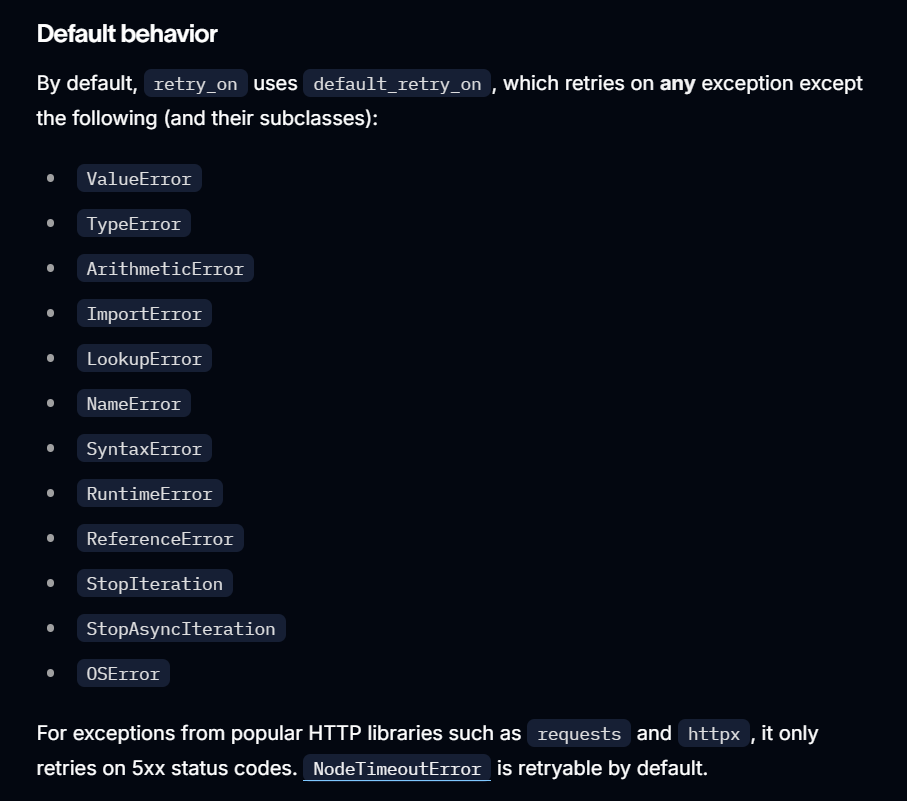

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy
from typing import TypedDict
from rich import print
class State(TypedDict):
    message: str

def chat_api(state: State) -> str:
    print(f"API called with message: {state['message']}")
    raise RuntimeError("The API call failed completely.")

graph = StateGraph(State)
graph.add_node("chat node", chat_api, retry_policy=RetryPolicy(max_attempts=3,retry_on=RuntimeError)) 
graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)
if __name__ == "__main__":
    workflow = graph.compile()
    
    try:
        # stream() shows you every single internal step/retry attempt as it happens
        for event in workflow.stream({"message": "Hello, world!"}):
            print(event)
    except RuntimeError:
        print("[bold red]Stopped after 3 failed attempts.[/bold red]")

API called with message: Hello, world!

API called with message: Hello, world!

API called with message: Hello, world!

Stopped after 3 failed attempts.

## with custom error


In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy
from typing import TypedDict
from rich import print

class CustomAPIError(Exception):
    """Raised when the custom external API fails."""
    pass

class State(TypedDict):
    message: str

def chat_api(state: State) -> str:
    print(f"API called with message: {state['message']}")
    raise CustomAPIError("The custom API call failed completely.")

graph = StateGraph(State)

graph.add_node(
    "chat node", 
    chat_api, 
    retry_policy=RetryPolicy(max_attempts=3, retry_on=CustomAPIError)
) 

graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

if __name__ == "__main__":
    workflow = graph.compile()
    
    try:
        for event in workflow.stream({"message": "Hello, world!"}):
            print(event)
    except CustomAPIError:  # 4. Catch your custom error at the top level
        print("[bold red]Stopped after 3 failed attempts.[/bold red]")

API called with message: Hello, world!

API called with message: Hello, world!

API called with message: Hello, world!

Stopped after 3 failed attempts.

In [3]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy,default_retry_on
from typing import TypedDict
from rich import print

class CustomAPIError(Exception):
    """Raised when the custom external API fails."""
    pass

def custom_retry_on(exc: BaseException) -> bool:
    if isinstance(exc, CustomAPIError):
        print("[yellow]CustomAPIError detected, will retry![/yellow]")
        return True # we want retry
    if isinstance(exc, RuntimeError):
        return True # we also want to retry on RuntimeError for demonstration

    return default_retry_on(exc)

class State(TypedDict):
    message: str

def chat_api(state: State) -> str:
    print(f"API called with message: {state['message']}")
    raise CustomAPIError("The custom API call failed completely.")

graph = StateGraph(State)

graph.add_node(
    "chat node", 
    chat_api, 
    retry_policy=RetryPolicy(max_attempts=3, retry_on=custom_retry_on)
) 

graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

if __name__ == "__main__":
    workflow = graph.compile()
    
    try:
        for event in workflow.stream({"message": "Hello, world!"}):
            print(event)
    except CustomAPIError:  # 4. Catch your custom error at the top level
        print("[bold red]Stopped after 3 failed attempts.[/bold red]")

API called with message: Hello, world!

CustomAPIError detected, will retry!

API called with message: Hello, world!

CustomAPIError detected, will retry!

API called with message: Hello, world!

CustomAPIError detected, will retry!

Stopped after 3 failed attempts.

## Inspect retry state

In [4]:
from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime
from langgraph.types import RetryPolicy
from typing_extensions import TypedDict

class State(TypedDict):
    result: str


def call_primary_api() -> str:
    # Simulate a failure in the primary API
    raise RuntimeError("Primary API failed")

def call_fallback_api() -> str:
    # Simulate a successful response from the fallback API
    return "Fallback API result"

def my_node(state: State, runtime: Runtime) -> State:
    if runtime.execution_info.node_attempt > 1:
        print(runtime)
        print(f"Checkpoint ID: {runtime.execution_info.checkpoint_id}")
        print(f"Checkpoint Namespace: {runtime.execution_info.checkpoint_ns}")
        print(f"Task ID: {runtime.execution_info.task_id}")
        print(f"Thread ID: {runtime.execution_info.thread_id}")
        print(f"Node Attempt: {runtime.execution_info.node_attempt}")
        print(f"Node First Attempt Time: {runtime.execution_info.node_first_attempt_time}")
        return {"result": call_fallback_api()}
    return {"result": call_primary_api()}

builder = StateGraph(State)
builder.add_node("my_node", my_node, retry_policy=RetryPolicy(max_attempts=3,retry_on=RuntimeError))
builder.add_edge(START, "my_node")
builder.add_edge("my_node", END)
if __name__ == "__main__":
    workflow = builder.compile()
    
    try:
        for event in workflow.stream({}):
            print(event)
    except RuntimeError:
        print("[bold red]Stopped after 3 failed attempts.[/bold red]")

Runtime(
    context=None,
    store=None,
    stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x0000017A4C7418A0>,
    heartbeat=<function _no_op_heartbeat at 0x0000017A4B4536A0>,
    previous=None,
    execution_info=ExecutionInfo(
        checkpoint_id='1f1603db-7045-6e45-8000-b1c92bea65e2',
        checkpoint_ns='my_node:f07bf300-eddd-81dc-d4b5-2e4f0cca008d',
        task_id='f07bf300-eddd-81dc-d4b5-2e4f0cca008d',
        thread_id=None,
        run_id=None,
        node_attempt=2,
        node_first_attempt_time=1780595360.4984388
    ),
    server_info=None,
    control=<langgraph.runtime.RunControl object at 0x0000017A4C760070>
)

Checkpoint ID: 1f1603db-7045-6e45-8000-b1c92bea65e2

Checkpoint Namespace: my_node:f07bf300-eddd-81dc-d4b5-2e4f0cca008d

Task ID: f07bf300-eddd-81dc-d4b5-2e4f0cca008d

Thread ID: None

Node Attempt: 2

Node First Attempt Time: 1780595360.4984388

{'my_node': {'result': 'Fallback API result'}}

# Timeouts

In [5]:
# this will stop if it doesnot completes with in 6 seconds else raise NodeTimeoutError
import asyncio
from datetime import timedelta
from typing import TypedDict
from rich import print
from langgraph.graph import StateGraph, START, END
# NodeTimeoutError is raised when the timeout completes
from langgraph.errors import NodeTimeoutError 
from langgraph.types import TimeoutPolicy

count = 0

class State(TypedDict):
    message: str

# 1. Convert to an async function so LangGraph can cancel it
async def chat_api(state: State) -> dict:
    global count
    while True:
        count += 1
        print(f"Loop running... Incrementing count to: {count*2}")
        # 2. Yield control briefly to let asyncio check for timeouts
        await asyncio.sleep(2)

graph = StateGraph(State)

# 3. Apply TimeoutPolicy using a small run timeout (e.g., 2 seconds)

# graph.add_node(
#     "chat node", 
#     chat_api, 
#     timeout=6
# ) 

# graph.add_node(
#     "chat node", 
#     chat_api, 
#     timeout=timedelta(seconds=6)
# ) 

# recommended way to add timeout policy
graph.add_node(
    "chat node", 
    chat_api, 
    timeout=TimeoutPolicy(run_timeout=6)
) 


graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

# 4. Use asyncio.run to execute the async graph workflow
async def main():
    workflow = graph.compile()
    try:
        async for event in workflow.astream({"message": "Hello, world!"}):
            print(event)
    except NodeTimeoutError:  # 5. Catch the specific timeout exception
        print("[bold red]\n[TIMEOUT TRIGGERED] Node forced to stop after 6 seconds![/bold red]")

if __name__ == "__main__":
    # Replace asyncio.run(main()) with this:
    await main()



Loop running... Incrementing count to: 2

Loop running... Incrementing count to: 4

Loop running... Incrementing count to: 6

Loop running... Incrementing count to: 8

[TIMEOUT TRIGGERED] Node forced to stop after 6 seconds!

In [6]:
# this will stop if it doesnot completes with in 6 seconds else raise NodeTimeoutError
import asyncio
from datetime import timedelta
from typing import TypedDict
from rich import print
from langgraph.graph import StateGraph, START, END
# NodeTimeoutError is raised when the timeout completes
from langgraph.errors import NodeTimeoutError 
from langgraph.types import TimeoutPolicy

count = 0

class State(TypedDict):
    message: str

# 1. Convert to an async function so LangGraph can cancel it
async def chat_api(state: State) -> dict:
    global count
    while True:
        count += 1
        print(f"Loop running... Incrementing count to: {count*2}")
        # 2. Yield control briefly to let asyncio check for timeouts
        await asyncio.sleep(2)

graph = StateGraph(State)

# recommended way to add timeout policy
graph.add_node(
    "chat node", 
    chat_api, 
    timeout=TimeoutPolicy(run_timeout=16,idle_timeout=12)
) 


graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

# 4. Use asyncio.run to execute the async graph workflow
async def main():
    workflow = graph.compile()
    try:
        async for event in workflow.astream({"message": "Hello, world!"}):
            print(event)
    except NodeTimeoutError:  # 5. Catch the specific timeout exception
        print("[bold red]\n[TIMEOUT TRIGGERED] Node forced to stop after 16 seconds but if remains idle for 12 seconds it will be stopped![/bold red]")

if __name__ == "__main__":
    # Replace asyncio.run(main()) with this:
    await main()



Loop running... Incrementing count to: 2

Loop running... Incrementing count to: 4

Loop running... Incrementing count to: 6

Loop running... Incrementing count to: 8

Loop running... Incrementing count to: 10

Loop running... Incrementing count to: 12

[TIMEOUT TRIGGERED] Node forced to stop after 16 seconds but if remains idle for 12 seconds it will be stopped!

In [7]:
# this will stop if it doesnot completes with in 6 seconds else raise NodeTimeoutError
import asyncio
from datetime import timedelta
from typing import TypedDict
from rich import print
from langgraph.graph import StateGraph, START, END
# NodeTimeoutError is raised when the timeout completes
from langgraph.errors import NodeTimeoutError 
from langgraph.types import TimeoutPolicy

count = 0

class State(TypedDict):
    message: str

# 1. Convert to an async function so LangGraph can cancel it
async def chat_api(state: State) -> dict:
    global count
    while True:
        count += 1
        print(f"Loop running... Incrementing count to: {count*2}")
        # 2. Yield control briefly to let asyncio check for timeouts
        await asyncio.sleep(2)

graph = StateGraph(State)

# recommended way to add timeout policy
graph.add_node(
    "chat node", 
    chat_api, 
    timeout=TimeoutPolicy(run_timeout=6,idle_timeout=2,refresh_on="heartbeat")
) 


graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

# 4. Use asyncio.run to execute the async graph workflow
async def main():
    workflow = graph.compile()
    try:
        async for event in workflow.astream({"message": "Hello, world!"}):
            print(event)
    except NodeTimeoutError:  # 5. Catch the specific timeout exception
        print("[bold red]\n[TIMEOUT TRIGGERED] Node forced to stop after 6 seconds but if remains idle for 2 seconds it will be stopped![/bold red]")
    
if __name__ == "__main__":
    # Replace asyncio.run(main()) with this:
    await main()



Loop running... Incrementing count to: 2

[TIMEOUT TRIGGERED] Node forced to stop after 6 seconds but if remains idle for 2 seconds it will be stopped!

In [8]:
import asyncio
from typing_extensions import TypedDict
from rich import print

# LangGraph and LangChain Imports
from langgraph.graph import StateGraph, START, END
from langgraph.types import TimeoutPolicy
from langgraph.errors import NodeTimeoutError
from langchain_core.runnables import RunnableConfig

# --- Helper Mock Functions ---
def fetch_batches():
    """Simulates fetching 5 sequential batches of data."""
    return [f"Batch-{i}" for i in range(1, 6)]

def process(batch: str):
    """Simulates processing work."""
    print(f"[yellow]Processing {batch}...[/yellow]")

# --- Graph Setup ---
class State(TypedDict):
    result: str

# Use RunnableConfig to safely extract the LangGraph runtime utility
async def long_running_node(state: State, config: RunnableConfig) -> State:
    # Extract the runtime object provided by the framework configuration
    runtime = config.get("configurable", {}).get("runtime")
    
    for batch in fetch_batches():
        process(batch)
        
        if runtime:
            print("[cyan]  -> Sending manual heartbeat to reset the idle timer...[/cyan]")
            runtime.heartbeat()  # Explicitly refreshes the idle timeout
            
        # IMPORTANT: Non-blocking async sleep allows LangGraph's timeout monitor
        # to jump in and check if the idle time threshold was violated.
        # We simulate a 2-second gap between batches.
        await asyncio.sleep(2)
        
    return {"result": "done"}

builder = StateGraph(State)

# Configured to stop ONLY if 3 seconds pass without an explicit runtime.heartbeat()
builder.add_node(
    "long_running_node",
    long_running_node,
    timeout=TimeoutPolicy(idle_timeout=3.0, refresh_on="heartbeat"),
)
builder.add_edge(START, "long_running_node")
builder.add_edge("long_running_node", END)

# --- Execution Block ---
async def main():
    workflow = builder.compile()
    try:
        async for event in workflow.astream({"result": ""}):
            print(event)
            
    # 1. Capture the exception instance using 'as e'
    except NodeTimeoutError as e:
        print("\n[bold red][TIMEOUT INTERRUPT] Details Captured From Exception Instance:[/bold red]")
        
        # 2. Access the instance attributes directly
        print(f"• Failed Node:      {e.node}")
        print(f"• Total Elapsed:    {e.elapsed:.2f} seconds")
        print(f"• Timeout Category: {e.kind}")
        print(f"• Idle Limit Set:  {e.idle_timeout} seconds")
        print(f"• Run Limit Set:   {e.run_timeout} seconds")


if __name__ == "__main__":
    # Execute natively within your current running interactive terminal loop
    await main()


Processing Batch-1...

Processing Batch-2...

[TIMEOUT INTERRUPT] Details Captured From Exception Instance:

• Failed Node:      long_running_node

• Total Elapsed:    3.00 seconds

• Timeout Category: idle

• Idle Limit Set:  3.0 seconds

• Run Limit Set:   None seconds

In [9]:
import asyncio
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy, TimeoutPolicy
from typing import TypedDict
from rich import print

class State(TypedDict):
    message: str

# 1. Define the node as an ASYNC function
async def chat_api(state: State) -> dict:
    print(f"[yellow]API called with message:[/yellow] {state['message']}")
    # Simulate a blocking or slow network call using async sleep
    # await asyncio.sleep(3)  # Uncomment this line to test timeout behavior
    await asyncio.sleep(1) 
    raise RuntimeError("The API call failed completely.")

graph = StateGraph(State)

# 2. TimeoutPolicy is now perfectly valid here
graph.add_node(
    "chat node", 
    chat_api, 
    retry_policy=RetryPolicy(max_attempts=5, retry_on=RuntimeError),
    timeout=TimeoutPolicy(run_timeout=2, idle_timeout=2)
) 

graph.add_edge(START, "chat node")
graph.add_edge("chat node", END)

# 3. Use an async main function to stream the graph
async def main():
    workflow = graph.compile()
    try:
        # Use an ASYNC loop (astream) to execute the workflow
        async for event in workflow.astream({"message": "Hello, world!"}):
            print(event)
    except Exception as e:
        print("\n[bold red]Stopped after failed attempts.[/bold red]")
        print(f"[red]Final Exception caught:[/red] {type(e).__name__}")

if __name__ == "__main__":
    await main()

API called with message: Hello, world!

API called with message: Hello, world!

API called with message: Hello, world!

API called with message: Hello, world!

API called with message: Hello, world!

Stopped after failed attempts.

Final Exception caught: RuntimeError

# Error Handling

In [10]:
import asyncio
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy, TimeoutPolicy,Command
from langgraph.errors import NodeError
from typing import TypedDict
from rich import print

class State(TypedDict):
    message: str


def my_error_handler(state:State,error:NodeError)->Command:
    print(f"Error occurred at: {error.node}")
    print(f"Error occurred: {error.error}")
    return Command(
        update={"message": f"Retrying after error: {str(error)}"},
        goto="print node"
    )

# 1. Define the node as an ASYNC function
async def chat_api(state: State) -> dict:
    print(f"[yellow]API called with message:[/yellow] {state['message']}")
    # Simulate a blocking or slow network call using async sleep
    # await asyncio.sleep(3)  # Uncomment this line to test timeout behavior
    await asyncio.sleep(1) 
    raise RuntimeError("The API call failed completely.")

def temp_node(state:State)->State:
    print("In temp node, doing some work...")
    return state
def print_node(state:State)->State:
    print(f"[green]In print node with message:[/green] {state['message']}")
    return state

graph = StateGraph(State)

# 2. TimeoutPolicy is now perfectly valid here
graph.add_node(
    "chat node", 
    chat_api, 
    retry_policy=RetryPolicy(max_attempts=2, retry_on=RuntimeError),
    timeout=TimeoutPolicy(run_timeout=2, idle_timeout=2),
    error_handler=my_error_handler
) 
graph.add_node("print node", print_node)
graph.add_node("temp node", temp_node)
graph.add_edge(START, "chat node")
graph.add_edge("chat node", "temp node")
graph.add_edge("temp node", "print node")
graph.add_edge("print node", END)
# 3. Use an async main function to stream the graph
async def main():
    workflow = graph.compile()
    try:
        # Use an ASYNC loop (astream) to execute the workflow
        async for event in workflow.astream({"message": "Hello, world!"}):
            print(event)
    except Exception as e:
        print("\n[bold red]Stopped after failed attempts.[/bold red]")
        print(f"[red]Final Exception caught:[/red] {type(e).__name__}")

if __name__ == "__main__":
    await main()

API called with message: Hello, world!

API called with message: Hello, world!

Error occurred at: chat node

Error occurred: The API call failed completely.

{
    '__error_handler__chat node': {
        'message': "Retrying after error: NodeError(node='chat node', error=RuntimeError('The API call failed 
completely.'))"
    }
}

In print node with message: Retrying after error: NodeError(node='chat node', error=RuntimeError('The API call 
failed completely.'))

{
    'print node': {
        'message': "Retrying after error: NodeError(node='chat node', error=RuntimeError('The API call failed 
completely.'))"
    }
}

In [11]:
from langgraph.errors import NodeError
from langgraph.types import Command, RetryPolicy
from langgraph.graph import StateGraph, START
from typing_extensions import TypedDict

class State(TypedDict):
    status: str

def reserve_inventory(state: State) -> State:
    return {"status": "reserved"}

def charge_payment(state: State) -> State:
    raise RuntimeError("payment timeout")

def payment_error_handler(state: State, error: NodeError) -> Command:
    return Command(
        update={"status": f"compensated_after_{error.node}: {error.error}"},
        goto="finalize",
    )

def finalize(state: State) -> State:
    return state

graph = (
    StateGraph(State)
    .add_node("reserve_inventory", reserve_inventory)
    .add_node(
        "charge_payment",
        charge_payment,
        retry_policy=RetryPolicy(max_attempts=3, retry_on=ConnectionError),
        error_handler=payment_error_handler,
    )
    .add_node("finalize", finalize)
    .add_edge(START, "reserve_inventory")
    .add_edge("reserve_inventory", "charge_payment")
    .compile()
)

if __name__ == "__main__":
    for event in graph.stream({"status": "initiated"}):
        print(event)
        

{'reserve_inventory': {'status': 'reserved'}}

{'__error_handler__charge_payment': {'status': 'compensated_after_charge_payment: payment timeout'}}

{'finalize': {'status': 'compensated_after_charge_payment: payment timeout'}}

## adding manually same rule for multiple nodes

In [12]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy
from typing import TypedDict
from rich import print
class State(TypedDict):
    message: str

def chat_api_1(state: State) -> str:
    return {"message": f"First API call failed with message: {state['message']}"}

def chat_api_2(state: State) -> str:
    print(f"API called with message: {state['message']}")
    raise RuntimeError("The API call failed completely.")

graph = StateGraph(State)
graph.add_node("first chat node", chat_api_1, retry_policy=RetryPolicy(max_attempts=3,retry_on=RuntimeError)) 
graph.add_node("second chat node", chat_api_2, retry_policy=RetryPolicy(max_attempts=3,retry_on=RuntimeError)) 
graph.add_edge(START, "first chat node")
graph.add_edge("first chat node", "second chat node")
graph.add_edge("second chat node", END)
if __name__ == "__main__":
    workflow = graph.compile()
    
    try:
        # stream() shows you every single internal step/retry attempt as it happens
        for event in workflow.stream({"message": "Hello, world!"}):
            print(event)
    except RuntimeError:
        print("[bold red]Stopped after 3 failed attempts.[/bold red]")

{'first chat node': {'message': 'First API call failed with message: Hello, world!'}}

API called with message: First API call failed with message: Hello, world!

API called with message: First API call failed with message: Hello, world!

API called with message: First API call failed with message: Hello, world!

Stopped after 3 failed attempts.

## adding  same rule for multiple nodes at once

In [13]:
import asyncio
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy, TimeoutPolicy, Command
from langgraph.errors import NodeError
from rich import print

class State(TypedDict):
    message: str

# 1. Corrected error handler name and signature
async def error_handler(state: State, error: NodeError) -> Command:
    print(f"Error occurred at: {error.node}")
    print(f"Error occurred: {error.error}")
    print(f"rediricting to end node")
    return Command(
        update={"message": f"Retrying after error: {str(error.error)}"},
        goto=END
    )

# 2. Made node async to support TimeoutPolicy
async def chat_api_1(state: State) -> dict:
    print(f"API called with message: {state['message']}")
    return {"message": f"forget this man"}

# 3. Made node async to support TimeoutPolicy
async def chat_api_2(state: State) -> dict:
    print(f"API called with message: {state['message']}")
    raise RuntimeError("The API call failed completely.")

# 4. Corrected handler mapping to 'error_handler'
graph = StateGraph(State).set_node_defaults(
    retry_policy=RetryPolicy(max_attempts=2, retry_on=RuntimeError),
    timeout=TimeoutPolicy(run_timeout=2, idle_timeout=2),
    error_handler=error_handler
)

graph.add_node("first chat node", chat_api_1) 
graph.add_node("second chat node", chat_api_2) 
graph.add_edge(START, "first chat node")
graph.add_edge("first chat node", "second chat node")
graph.add_edge("second chat node", END)

async def main():
    workflow = graph.compile()
    try:
        # Standard async streaming for compiled workflows
        async for event in workflow.astream({"message": "All I Want Was Love and What I Get Is The Pain!"}):
            print(event)
    except Exception as e:
        print(f"[bold red]Workflow encountered an unhandled exception: {e}[/bold red]")

if __name__ == "__main__":
    await main()


API called with message: All I Want Was Love and What I Get Is The Pain!

{'first chat node': {'message': 'forget this man'}}

API called with message: forget this man

API called with message: forget this man

Error occurred at: second chat node

Error occurred: The API call failed completely.

rediricting to end node

{'__default_error_handler__': {'message': 'Retrying after error: The API call failed completely.'}}

### there is RunnableConfig as optional third parameter

In [14]:
import asyncio
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy, TimeoutPolicy, Command
from langgraph.errors import NodeError
from langchain_core.runnables import RunnableConfig
from rich import print
config={"configurable":{"thread_id":"thread_123"}}
class State(TypedDict):
    message: str

# 1. Corrected error handler name and signature
async def error_handler(state: State, error: NodeError, config: RunnableConfig) -> Command:
    print(f"Error occurred at: {error.node}")
    print(f"Error occurred: {error.error}")
    print(f"Thread Id received in error handler: {config['configurable']['thread_id']}")
    print(f"rediricting to end node")
    return Command(
        update={"message": f"Retrying after error: {str(error.error)}"},
        goto=END
    )

# 2. Made node async to support TimeoutPolicy
async def chat_api_1(state: State) -> dict:
    print(f"API called with message: {state['message']}")
    return {"message": f"forget this man"}

# 3. Made node async to support TimeoutPolicy
async def chat_api_2(state: State) -> dict:
    print(f"API called with message: {state['message']}")
    raise RuntimeError("The API call failed completely.")

# 4. Corrected handler mapping to 'error_handler'
graph = StateGraph(State).set_node_defaults(
    retry_policy=RetryPolicy(max_attempts=2, retry_on=RuntimeError),
    timeout=TimeoutPolicy(run_timeout=2, idle_timeout=2),
    error_handler=error_handler
)

graph.add_node("first chat node", chat_api_1) 
graph.add_node("second chat node", chat_api_2) 
graph.add_edge(START, "first chat node")
graph.add_edge("first chat node", "second chat node")
graph.add_edge("second chat node", END)

async def main():
    workflow = graph.compile()
    try:
        # Standard async streaming for compiled workflows
        async for event in workflow.astream({"message": "All I Want Was Love and What I Get Is The Pain!"},config=config):
            print(event)
    except Exception as e:
        print(f"[bold red]Workflow encountered an unhandled exception: {e}[/bold red]")

if __name__ == "__main__":
    await main()


API called with message: All I Want Was Love and What I Get Is The Pain!

{'first chat node': {'message': 'forget this man'}}

API called with message: forget this man

API called with message: forget this man

Error occurred at: second chat node

Error occurred: The API call failed completely.

Thread Id received in error handler: thread_123

rediricting to end node

{'__default_error_handler__': {'message': 'Retrying after error: The API call failed completely.'}}

## Graceful Shutdown

In [15]:
from langgraph.runtime import RunControl
from langgraph.errors import GraphDrained

control = RunControl()

# In a signal handler or supervisor:
# control.request_drain("sigterm")

try:
    async for event in workflow.astream({"message": "All I Want Was Love and What I Get Is The Pain!"},config=config,control=control):
        print(event)
except GraphDrained as e:
    # The graph stopped early and saved a checkpoint.
    # Resume later with the same config.
    print(f"Drained: {e.reason}")
except Exception as e:
    print(f"Graph failed with error: {e}")

{
    'first chat node': {
        'message': 'First API call failed with message: All I Want Was Love and What I Get Is The Pain!'
    }
}

API called with message: First API call failed with message: All I Want Was Love and What I Get Is The Pain!

API called with message: First API call failed with message: All I Want Was Love and What I Get Is The Pain!

API called with message: First API call failed with message: All I Want Was Love and What I Get Is The Pain!

Graph failed with error: The API call failed completely.

In [16]:
import time
import logging
import signal
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.runtime import RunControl
from langgraph.errors import GraphDrained
from rich import print
# Configure logging to monitor the drainage behavior
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger(__name__)

# 1. Define graph state and nodes
class GraphState(TypedDict):
    step: int
    data: str

def slow_processing_node(state: GraphState) -> GraphState:
    current_step = state.get("step", 0) + 1
    log.info(f"Executing node step {current_step}...")
    
    # Simulate a time-consuming node task
    time.sleep(2) 
    # raise GraphDrained(reason=f"Draining at step {current_step} for graceful shutdown.")
    return {"step": current_step, "data": f"Processed step {current_step}"}

# 2. Build and compile the graph with persistent memory checkpointer
builder = StateGraph(GraphState)
builder.add_node("process", slow_processing_node)
builder.add_edge(START, "process")
builder.add_edge("process", END)

# MemorySaver acts as the persistent storage layer for resuming execution
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# 3. Execution configuration and runtime controls
config = {"configurable": {"thread_id": "resumable-workflow-thread-101"}}
inputs = {"step": 0, "data": "Initial payload"}

control = RunControl()

# Bind SIGTERM to cooperative drainage
signal.signal(signal.SIGTERM, lambda *_: control.request_drain("sigterm"))

# 4. Invoke with drainage handling
try:
    log.info("Starting graph execution. Send SIGTERM to test draining.")
    result = graph.invoke(inputs, config, control=control)
    log.info("Graph completed normally: %s", result)
    
except GraphDrained as e:
    log.warning("Graph execution was safely drained: %s", e.reason)
    log.info("State was securely snapshotted. Ready to resume on startup.")
    
    # --- Simulate Startup / Resume Logic ---
    log.info("Simulating machine restart and resuming using the same config...")
    
    # Resume execution passing None as inputs since state is already in the checkpointer
    resumed_result = graph.invoke(None, config)
    log.info("Graph successfully resumed and finished: %s", resumed_result)


2026-06-04 23:35:10,242 [INFO] Starting graph execution. Send SIGTERM to test draining.
2026-06-04 23:35:10,247 [INFO] Executing node step 1...
2026-06-04 23:35:12,253 [INFO] Graph completed normally: {'step': 1, 'data': 'Processed step 1'}
